# 3.5_BreastNet3D — Corrected Full-Loss Hybrid Reconstruction

## What This Notebook Fixes

This notebook is a corrected and upgraded version of `3_breastnet3d.ipynb`. 
Five silent bugs were identified in the original pipeline that prevented the architecture from running as designed:

| # | Bug | Impact |
|---|-----|--------|
| 1 | `Encoder2D` hardcoded to `inc=5`; `input_10ch` never used in fine-tuning | Otsu error-correction prior disabled |
| 2 | `total_variation_3d`, `inter_mammary_valley_loss`, `sparsity_loss` defined but never called | Sternal cleft separation and anti-bloat off |
| 3 | `render_projection` called inside `torch.amp.autocast` | FP16 underflow → zero gradient signal for sparse views |
| 4 | `gaussian_filter(sigma=2.0)` applied before `marching_cubes` | Blurs away the valley the loss worked to carve |
| 5 | `marching_cubes` uses `level=0.02` in one cell and `level=0.5` in another | Non-reproducible mesh geometry |

This notebook also introduces **Cross-View Attention** in the encoder as an architectural upgrade.

---
> **Hardware target:** NVIDIA Turing (RTX 2080 Ti), pure FP32, AdamW + `clip_grad_norm_(1.0)`  
> **Dataset:** DMR-IR (5-view clinical thermography, Benign/Malignant stratified)  
> **Baseline to beat:** Dice > 0.82, HD95 stable across 3-fold CV

## Cell 1 — Install Dependencies

Install all required packages. `tifffile` reads raw 16-bit radiometric `.tiff` thermograms. 
`scikit-image` provides `marching_cubes` for isosurface extraction. `plotly` renders the interactive 3D thermal mesh.

In [32]:
!uv pip install torch torchvision tifffile opencv-python numpy scipy scikit-image
!uv pip install matplotlib tqdm pandas plotly ipywidgets
print('Dependencies installed.')

Using Python 3.11.9 environment at: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv
Checked 7 packages in 5ms
Using Python 3.11.9 environment at: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv
Checked 5 packages in 5ms
Dependencies installed.


## Cell 2 — Imports & Global Seed

All imports are consolidated here. `torch.backends.cudnn.benchmark = True` enables cuDNN auto-tuner 
for fixed input sizes. `torch.backends.cudnn.deterministic = False` is left as default — setting it `True` 
with benchmark would cause a contradiction and is unnecessary given we seed explicitly.

In [33]:
import os, sys, time, random, json, math, glob, struct
import numpy as np
import cv2
import tifffile
import pandas as pd
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import scipy.ndimage
from scipy.ndimage import gaussian_filter
from skimage.measure import marching_cubes

import plotly.graph_objects as go

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
VRAM: 11.3 GB


## Cell 3 — Configuration

All tunable hyperparameters and paths are declared in a single dictionary. 
**Update `PATHS` before running.** Loss weights are tuned for DMR-IR scale:

$$\mathcal{L}_{total} = \mathcal{L}_{sil} + \lambda_{TV}\,\mathcal{L}_{TV} + \lambda_{valley}\,\mathcal{L}_{valley} + \lambda_{sparse}\,\mathcal{L}_{sparse}$$

where $\lambda_{TV}=0.001$, $\lambda_{valley}=0.005$, $\lambda_{sparse}=0.001$. These were chosen so the 
auxiliary losses contribute roughly 5–10% of total loss magnitude at epoch 1, scaling to zero influence 
if the silhouette loss dominates, preventing the regularizers from collapsing the volume prematurely.

In [34]:
PATHS = {
    'otsu_dir':   r'../../data/organized_by_patient_otsu',
    'unet_dir':   r'../../data/organized_by_patient_unet',
    'tiff_base':  r'../../data/organized_by_patient',
    'unet_ckpt':  r'../../UNET_Segmentation/breast_segmentation_unet_best_gpu.pth',
    'base_ckpt':  r'checkpoints_3d/3dbreastnet_best.pth',
    'ckpt_dir':   'checkpoints_3d_v35',
}

CFG = {
    'epochs':       400,
    'ft_epochs':    75,
    'batch_size':   6,
    'lr':           1e-4,
    'ft_lr':        2e-5,
    'betas':        (0.9, 0.999),
    'n_per_view':   4,
    'patience':     25,
    'train_split':  0.78,
    'img_sz':       128,
    'vol_sz':       128,
}

LOSS_W = {
    'tv3d':   0.01,
    'valley': 0.01,
    'sparse': 0.002,
    'bce':    0.15,
}

VIEW_WINDOWS  = [(-90., -67.5), (-67.5, -22.5), (-22.5, 22.5), (22.5, 67.5), (67.5, 90.)]
VAL_ANGLES    = [-90., -45., 0., 45., 90.]
VIEW_NAMES    = ['Right Lateral (-90°)', 'Right Oblique (-45°)', 'Frontal (0°)',
                 'Left Oblique (45°)', 'Left Lateral (90°)']

MC_LEVEL       = 0.5
GAUSSIAN_SIGMA = 0.8

Path(PATHS['ckpt_dir']).mkdir(parents=True, exist_ok=True)
print('Config loaded.')

Config loaded.


## Cell 4 — Building Blocks

### DoubleConv2D / DoubleConv3D

Each block applies two convolutions with BatchNorm and ReLU, implementing:

$$\mathbf{x}_{out} = \text{ReLU}(\text{BN}(W_2 * \text{ReLU}(\text{BN}(W_1 * \mathbf{x}_{in}))))$$

Kaiming normal initialization is applied to all conv layers, setting the initial weight variance to 
$\sigma^2 = \frac{2}{n_{fan\_out}}$, which prevents vanishing gradients under ReLU activation.

### Weight Initialization

The decoder output bias is initialized to $-4.0$ so the Sigmoid activation produces near-zero initial density 
($\sigma(-4) \approx 0.018$). This starts the volume nearly empty and forces the network to learn to 
*add* structure — much more stable than starting from a dense blob.

In [35]:
class DoubleConv2D(nn.Module):
    def __init__(self, inc, outc, drop=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Dropout2d(drop) if drop > 0 else nn.Identity(),
            nn.Conv2d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True))
    def forward(self, x): return self.block(x)


class DoubleConv3D(nn.Module):
    def __init__(self, inc, outc, drop=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm3d(outc), nn.ReLU(True),
            nn.Dropout3d(drop) if drop > 0 else nn.Identity(),
            nn.Conv3d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm3d(outc), nn.ReLU(True))
    def forward(self, x): return self.block(x)


def _init(m):
    if isinstance(m, (nn.Conv2d, nn.Conv3d, nn.ConvTranspose2d, nn.ConvTranspose3d)):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.constant_(m.bias, 0)
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm3d)):
        nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.constant_(m.bias, 0)

print('Building blocks defined.')

Building blocks defined.


## Cell 5 — U-Net Segmentor (Frozen)

The U-Net is loaded from a pre-trained checkpoint and frozen throughout all training. 
Its role is purely inferential: given a raw thermal image $I \in \mathbb{R}^{1 \times H \times W}$, 
it produces a breast probability mask $M_{\text{unet}} \in [0,1]^{H \times W}$.

The skip connections implement:

$$\mathbf{d}_k = \text{DoubleConv}(\text{Upsample}(\mathbf{d}_{k+1}) \oplus \mathbf{e}_k)$$

where $\oplus$ denotes channel-wise concatenation. This preserves spatial frequency information 
lost during the encoder's downsampling.

In [36]:
class DoubleConv(nn.Module):
    def __init__(self, inc, outc, drop=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Conv2d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Dropout2d(drop) if drop > 0 else nn.Identity())
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_c=1, out_c=1, b=64, drop=0.2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(in_c, b, 0.0);      self.enc2 = DoubleConv(b, b*2, 0.0)
        self.enc3 = DoubleConv(b*2, b*4, 0.1);     self.enc4 = DoubleConv(b*4, b*8, 0.1)
        self.bottleneck = DoubleConv(b*8, b*16, drop)
        self.up4 = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = DoubleConv(b*16, b*8, 0.1)
        self.up3 = nn.ConvTranspose2d(b*8, b*4, 2, stride=2)
        self.dec3 = DoubleConv(b*8, b*4, 0.1)
        self.up2 = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.dec2 = DoubleConv(b*4, b*2, 0.0)
        self.up1 = nn.ConvTranspose2d(b*2, b, 2, stride=2)
        self.dec1 = DoubleConv(b*2, b, 0.0)
        self.out  = nn.Conv2d(b, out_c, 1)

    def forward(self, x):
        e1 = self.enc1(x);               e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2));   e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out(d1)

print('UNet defined.')

UNet defined.


## Cell 6 — Cross-View Attention Encoder (FIX 1 + Architectural Upgrade)

### FIX 1: 10-Channel Input
The original `Encoder2D` was hardcoded to `inc=5` and the fine-tuning loop discarded `input_10ch`. 
This encoder correctly takes **10 channels** (5 Otsu + 5 U-Net masks).

### Cross-View Attention

After the shared backbone encodes each view to a 256-dim feature vector, the 5 view features 
are passed through Multi-Head Attention:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

where $Q = K = V \in \mathbb{R}^{5 \times 256}$ (all 5 views attend to each other). 
A residual connection and LayerNorm follow:

$$\mathbf{v}'_i = \text{LayerNorm}(\mathbf{v}_i + \text{Attn}(\mathbf{v}_i, \{\mathbf{v}_j\}))$$

**Why this matters:** if the U-Net mask for Left Lateral is blank, the attention can pull 
spatial geometry from the Frontal and Left Oblique features *before* the bottleneck collapses 
everything — performing the error correction at the feature level rather than relying solely 
on the Otsu channel fallback.

In [37]:
class Encoder2D(nn.Module):
    """
    10-channel input with REAL Cross-View Attention + View Position Embeddings.
    
    Each of the 5 views (2ch: Otsu + UNet) is processed INDEPENDENTLY
    through a shared CNN backbone to produce 5 DIFFERENT feature tokens.
    Learnable position embeddings tell the attention which view is which.
    Then multi-head self-attention lets views communicate.
    
    Architecture:
        [B, 10, 128, 128]  — 5 Otsu + 5 U-Net channels
            ↓  Split into 5 views of 2 channels each
        5 × [B, 2, 128, 128]  — per-view pairs
            ↓  Shared backbone (6 conv+pool stages)
        [B, 5, 256]        — 5 DIFFERENT per-view feature vectors
            ↓  + view_pos embeddings (tells attention which angle is which)
            ↓  MultiheadAttention (views attend to each other)
        [B, 5, 256]        — cross-view-aware features
            ↓  Flatten + Linear
        [B, 2048]          — latent vector
    """
    def __init__(self, drop=0.25):
        super().__init__()
        self.backbone = nn.Sequential(
            DoubleConv2D(2, 32, 0),   nn.MaxPool2d(2),
            DoubleConv2D(32, 64, 0),  nn.MaxPool2d(2),
            DoubleConv2D(64, 128, drop), nn.MaxPool2d(2),
            DoubleConv2D(128, 256, drop), nn.MaxPool2d(2),
            DoubleConv2D(256, 256, drop), nn.MaxPool2d(2),
            DoubleConv2D(256, 256, drop), nn.MaxPool2d(2),
        )
        
        self.view_proj = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(256 * 2 * 2, 256)
        )
        
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=256, num_heads=4,
            dropout=drop, batch_first=True
        )
        self.attn_norm = nn.LayerNorm(256)
        self.view_pos = nn.Parameter(torch.randn(1, 5, 256) * 0.02)
        
        self.fc = nn.Linear(256 * 5, 2048)
        
        self.apply(_init)

    def forward(self, x):
        B = x.size(0)
        
        view_tokens = []
        for i in range(5):
            view_2ch = torch.stack([x[:, i], x[:, i + 5]], dim=1)
            feat = self.backbone(view_2ch)
            token = self.view_proj(feat.view(B, -1))
            view_tokens.append(token)
        
        tokens = torch.stack(view_tokens, dim=1)
        tokens = tokens + self.view_pos
        
        attn_out, _ = self.cross_attn(tokens, tokens, tokens)
        tokens = self.attn_norm(tokens + attn_out)
        
        return self.fc(tokens.reshape(B, 5 * 256))


print('Encoder2D (CrossViewAttention + ViewPosEmbeddings + 2048-d) defined.')

Encoder2D (CrossViewAttention + ViewPosEmbeddings + 2048-d) defined.


## Cell 7 — 3D Decoder (Unchanged from Original)

The decoder expands the 1000-dim latent vector into a full $128^3$ occupancy volume. 
The expansion proceeds in 6 stages of transposed convolution:

$$z \xrightarrow{\text{FC}} [B, 512, 2, 2, 2] \xrightarrow{\times 6\,\text{ConvTranspose3d}} [B, 1, 128, 128, 128]$$

Each doubling step: $2 \to 4 \to 8 \to 16 \to 32 \to 64 \to 128$.

**Gradient checkpointing** is applied to the last three (most memory-expensive) decoder stages. 
This trades compute for memory: intermediate activations are discarded and recomputed during backprop, 
reducing peak VRAM usage by approximately 30% at the cost of one extra forward pass per checkpoint.

**Output bias initialization:** $b_{out} = -4.0 \Rightarrow \sigma(-4) \approx 0.018$. 
The network starts nearly empty and learns to sculpt volume — much more stable than starting dense.

In [38]:
class Decoder3D(nn.Module):
    """Pure FP32 decoder. No gradient checkpointing (causes NaN on Turing)."""
    def __init__(self, drop=0.25):
        super().__init__()
        self.fc = nn.Linear(2048, 512 * 2 * 2 * 2)  # Updated for 2048-d latent
        self.up1 = nn.ConvTranspose3d(512, 256, 2, stride=2); self.d1 = DoubleConv3D(256, 256, drop)
        self.up2 = nn.ConvTranspose3d(256, 128, 2, stride=2); self.d2 = DoubleConv3D(128, 128, drop)
        self.up3 = nn.ConvTranspose3d(128,  64, 2, stride=2); self.d3 = DoubleConv3D(64,   64, drop)
        self.up4 = nn.ConvTranspose3d( 64,  32, 2, stride=2); self.d4 = DoubleConv3D(32,   32, 0)
        self.up5 = nn.ConvTranspose3d( 32,  16, 2, stride=2); self.d5 = DoubleConv3D(16,   16, 0)
        self.up6 = nn.ConvTranspose3d( 16,   8, 2, stride=2); self.d6 = DoubleConv3D(8,     8, 0)
        self.out = nn.Sequential(nn.Conv3d(8, 1, 1), nn.Sigmoid())
        self.apply(_init)
        nn.init.constant_(self.out[0].bias, -4.0)

    def forward(self, x):
        x = self.fc(x).view(x.size(0), 512, 2, 2, 2)
        x = self.d1(self.up1(x)); x = self.d2(self.up2(x))
        x = self.d3(self.up3(x)); x = self.d4(self.up4(x))
        x = self.d5(self.up5(x)); x = self.d6(self.up6(x))
        return self.out(x)


print('Decoder3D defined (pure FP32, no checkpointing, 2048-d input).')

Decoder3D defined (pure FP32, no checkpointing, 2048-d input).


## Cell 8 — Differentiable Raymarching Renderer (FIX 3)

### FIX 3: Render outside `torch.amp.autocast`

In the original notebook, `render_projection` was called inside the `autocast` context. 
On Turing (FP16), `F.grid_sample` can underflow for sparse volumes: the Beer-Lambert sum 
$\sum_d V_d \approx 0$ produces $\exp(-0) = 1$, making the projection identically zero — 
zero gradient, zero learning signal for that view. This function must always be called 
with the volume already cast to `float32` and **outside** any autocast block.

### Beer-Lambert Volume Rendering

The renderer simulates a camera at angle $\theta$ around the Y-axis. The rotation matrix is:

$$R_y(\theta) = \begin{bmatrix} \cos\theta & 0 & \sin\theta & 0 \\ 0 & 1 & 0 & 0 \\ -\sin\theta & 0 & \cos\theta & 0 \end{bmatrix}$$

The volume $V$ is resampled along rotated rays using `F.grid_sample`. The accumulated opacity 
along each ray is computed via the Beer-Lambert law:

$$P(h, w) = 1 - \exp\!\left(-\sum_{d=1}^{D} V_{rot}(d, h, w)\right)$$

This is differentiable — gradients flow from the 2D projection loss backward through the 
virtual camera and into every voxel of the 3D grid.

In [39]:
def render_projection(volume, theta_deg):
    """
    FIX 3: Always call this function OUTSIDE torch.amp.autocast.
    The caller must ensure volume.dtype == torch.float32.

    Args:
        volume:    [B, 1, D, H, W] float32 occupancy volume
        theta_deg: scalar or [B] tensor of rotation angles in degrees

    Returns:
        proj: [B, 1, H, W] Beer-Lambert 2D projection in [0, 1]
    """
    assert volume.dtype == torch.float32, \
        'render_projection must receive float32. Cast volume before calling.'

    B, C, D, H, W = volume.shape
    dev = volume.device

    if not isinstance(theta_deg, torch.Tensor):
        theta_deg = torch.full((B,), float(theta_deg), device=dev, dtype=torch.float32)
    theta_deg = theta_deg.float()

    rad = theta_deg * math.pi / 180.0
    c, s = torch.cos(rad), torch.sin(rad)
    z, o = torch.zeros_like(rad), torch.ones_like(rad)

    # Y-axis rotation matrix [B, 3, 4]
    mat = torch.stack([
        torch.stack([ c, z, s, z], -1),
        torch.stack([ z, o, z, z], -1),
        torch.stack([-s, z, c, z], -1),
    ], -2)

    grid = F.affine_grid(mat, volume.shape, align_corners=False)
    Vr   = F.grid_sample(volume, grid, mode='bilinear',
                         padding_mode='zeros', align_corners=False)
    # Beer-Lambert accumulation along depth axis
    return 1.0 - torch.exp(-Vr.squeeze(1).sum(dim=1, keepdim=True))


print('render_projection defined (FP32-safe, assertion guarded).')

render_projection defined (FP32-safe, assertion guarded).


## Cell 9 — Loss Functions (FIX 2)

### FIX 2: All Four Losses Now Active

In the original fine-tuning cell, `total_variation_3d`, `inter_mammary_valley_loss`, and 
`sparsity_loss` were defined but never called. The training loop only used `dice_loss`. 
All four are now wired into the training loop.

### Dice Loss

$$\mathcal{L}_{Dice}(P, T) = 1 - \frac{2 \sum P \cdot T}{\sum P^2 + \sum T^2 + \varepsilon}$$

Dice is preferred over pixel-wise BCE for binary silhouettes because it is invariant to the 
foreground/background area ratio — critical when the breast region is a small fraction of the 128×128 frame.

### Silhouette Loss (Dice + BCE)

$$\mathcal{L}_{sil}(P, T) = \mathcal{L}_{Dice}(P, T) + 0.15 \cdot \text{BCE}(P, T)$$

The small BCE term penalizes confident wrong predictions and helps stabilize early training 
when Dice gradients are weak (both P and T near zero).

### Total Variation 3D

$$\mathcal{L}_{TV} = \mathbb{E}[|V_{d+1,h,w} - V_{d,h,w}|] + \mathbb{E}[|V_{d,h+1,w} - V_{d,h,w}|] + \mathbb{E}[|V_{d,h,w+1} - V_{d,h,w}|]$$

Minimizing TV forces adjacent voxels to have similar density — producing a solid, connected 
tissue mass rather than a cloud of disconnected noise.

### Inter-Mammary Valley Loss

$$\mathcal{L}_{valley} = \mathbb{E}\left[V_{:,:,:, W/2-4:W/2+4}\right]$$

Penalizes density in the 8-voxel-wide sagittal center slice. This enforces the sternal cleft 
(inter-mammary valley) — preventing both breasts from fusing into a single mass.

### L1 Sparsity Loss

$$\mathcal{L}_{sparse} = \mathbb{E}[|V|]$$

Pushes the network to minimize total occupied volume, carving away the 'bloat' inherent to 
the visual hull — where any geometry consistent with all 5 views is accepted.

In [40]:
def dice_loss(pred, target, eps=1e-6):
    p, t = pred.float(), target.float()
    num  = 2 * (p * t).sum()
    den  = p.pow(2).sum() + t.pow(2).sum() + eps
    return 1 - num / den


def silhouette_loss(pred, target, bce_w=LOSS_W['bce']):
    """Dice + weighted BCE. Pred must be in (0,1) — clamp before BCE."""
    dl  = dice_loss(pred, target)
    bce = F.binary_cross_entropy(
        torch.clamp(pred.float(), 1e-7, 1 - 1e-7), target.float())
    return dl + bce_w * bce


def total_variation_3d(vol):
    """Anisotropic 3D TV over D, H, W axes. vol: [B, 1, D, H, W]."""
    dx = torch.abs(vol[:, :, 1:, :, :]  - vol[:, :, :-1, :, :] ).mean()
    dy = torch.abs(vol[:, :, :, 1:, :]  - vol[:, :, :, :-1, :] ).mean()
    dz = torch.abs(vol[:, :, :, :, 1:]  - vol[:, :, :, :, :-1] ).mean()
    return dx + dy + dz


def inter_mammary_valley_loss(vol):
    """Penalise density in the 8-voxel sagittal center slice. vol: [B,1,D,H,W]."""
    mid = vol.shape[-1] // 2
    return vol[:, :, :, :, mid - 4 : mid + 4].mean()


def sparsity_loss(vol):
    """L1 sparsity — minimises total occupied volume."""
    return torch.mean(torch.abs(vol))


def composite_loss(vol, proj, target_mask, w=LOSS_W):
    """
    FIX 2: Single entry point that combines all four losses.
    Called once per view angle; regularizers are computed once per batch
    by the caller and passed in, or computed here from vol.

    Returns:
        total_loss, dict of component losses for logging.
    """
    l_sil    = silhouette_loss(proj, target_mask)
    l_tv     = total_variation_3d(vol)
    l_valley = inter_mammary_valley_loss(vol)
    l_sparse = sparsity_loss(vol)
    total = l_sil + w['tv3d'] * l_tv + w['valley'] * l_valley + w['sparse'] * l_sparse
    return total, {'sil': l_sil.item(), 'tv': l_tv.item(),
                   'valley': l_valley.item(), 'sparse': l_sparse.item()}


print('Loss functions defined (all four active).')

Loss functions defined (all four active).


## Cell 10 — Evaluation Metrics

### HD95 — 95th Percentile Hausdorff Distance

The Hausdorff distance measures the worst-case surface mismatch between prediction $P$ and target $T$:

$$H(P, T) = \max\left(\sup_{p \in \partial P} \inf_{t \in \partial T} d(p,t),\; \sup_{t \in \partial T} \inf_{p \in \partial P} d(p,t)\right)$$

HD95 uses the 95th percentile instead of the supremum, making it robust to isolated outlier voxels. 
It is computed on binary contours (surface voxels) extracted via morphological erosion.

In [41]:
def hd95(p_bin, t_bin):
    """95th-percentile Hausdorff on binary 2D or 3D arrays."""
    if p_bin.sum() == 0 or t_bin.sum() == 0:
        return float(max(p_bin.shape))
    pe = p_bin ^ scipy.ndimage.binary_erosion(p_bin)
    te = t_bin ^ scipy.ndimage.binary_erosion(t_bin)
    dtp = scipy.ndimage.distance_transform_edt(~pe)
    dtt = scipy.ndimage.distance_transform_edt(~te)
    d1  = np.percentile(dtt[pe], 95) if pe.sum() > 0 else float(max(p_bin.shape))
    d2  = np.percentile(dtp[te], 95) if te.sum() > 0 else float(max(p_bin.shape))
    return float(max(d1, d2))


print('Metrics defined.')

Metrics defined.


## Cell 11 — Dataset Classes

### HybridPatientDataset (Otsu-dir + U-Net-dir)

Loads pre-computed Otsu and U-Net masks from disk. Returns the full 10-channel tensor 
`input_10ch = [Otsu_5ch | UNet_5ch]` alongside `target_5ch` for loss computation.

### PatientDataset (TIFF-based, for fine-tuning)

Reads raw 16-bit radiometric `.tiff` files, normalises each view independently:

$$I_{norm}(x,y) = \frac{I(x,y) - I_{min}}{I_{max} - I_{min} + \varepsilon}$$

and generates U-Net masks on-the-fly at inference time. The Otsu mask is approximated from the 
normalised thermal image using Otsu's threshold as a post-hoc computation, producing the 10-channel 
input required by the fixed encoder.

In [42]:
def build_hybrid_patients(otsu_dir, unet_dir):
    otsu_p = set(f for f in os.listdir(otsu_dir) if f.startswith('Patient_'))
    unet_p = set(f for f in os.listdir(unet_dir) if f.startswith('Patient_'))
    valid  = sorted(otsu_p & unet_p)
    benign, malignant = [], []
    for p in valid:
        subs = [d for d in os.listdir(os.path.join(otsu_dir, p))
                if os.path.isdir(os.path.join(otsu_dir, p, d))]
        if not subs: continue
        cat = subs[0]
        (benign if 'benign' in cat.lower() else malignant).append((p, cat))
    print(f'Patients: {len(valid)} | B={len(benign)} M={len(malignant)}')
    return benign, malignant


VIEW_ORDER = ['Right Lateral', 'Right Oblique', 'Anterior', 'Left Oblique', 'Left Lateral']


class HybridPatientDataset(Dataset):
    """Returns 10-channel input (5 Otsu + 5 UNet) and 5-channel target."""
    def __init__(self, patient_tuples, otsu_dir, unet_dir, img_sz=128):
        self.patients = patient_tuples
        self.otsu_dir, self.unet_dir, self.img_sz = otsu_dir, unet_dir, img_sz

    def __len__(self): return len(self.patients)

    def _load_mask(self, folder, view, sz):
        files = [f for f in glob.glob(os.path.join(folder, '*.png'))
                 if view in os.path.basename(f)]
        if files:
            m = cv2.imdecode(np.fromfile(files[0], dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
            m = cv2.resize(m, (sz, sz), interpolation=cv2.INTER_NEAREST)
            return torch.from_numpy(m).float() / 255.0
        return torch.zeros(sz, sz)

    def __getitem__(self, idx):
        pid, cat = self.patients[idx]
        otsu_f = os.path.join(self.otsu_dir, pid, cat)
        unet_f = os.path.join(self.unet_dir, pid, cat)
        sz = self.img_sz
        otsu_t = torch.stack([self._load_mask(otsu_f, v, sz) for v in VIEW_ORDER])
        unet_t = torch.stack([self._load_mask(unet_f, v, sz) for v in VIEW_ORDER])
        return {
            'input_10ch': torch.cat([otsu_t, unet_t], dim=0),  # [10, 128, 128]
            'target_5ch': unet_t,                               # [5, 128, 128]
            'patient_id': pid, 'label': cat,
        }


@dataclass
class PatientGroup:
    patient_id: str
    label: str
    views: Dict[str, Path]


def get_view_key(filename):
    n = filename.lower()
    if 'right later' in n: return 'RL'
    if 'right obli'  in n: return 'RO'
    if 'frontal' in n or 'anterior' in n: return 'F'
    if 'left obliq'  in n: return 'LO'
    if 'left later'  in n: return 'LL'
    return None


def build_patient_groups(tiff_base):
    tb, pd_ = Path(tiff_base), {}
    for tp in tb.rglob('*.tiff'):
        parts = tp.relative_to(tb).parts
        if len(parts) < 3: continue
        pid, lab, fn = parts[0], parts[1], parts[-1]
        vk = get_view_key(fn)
        if not vk: continue
        key = (pid, lab)
        if key not in pd_: pd_[key] = {'views': {}}
        pd_[key]['views'][vk] = tp
    groups, nb_, nm = [], 0, 0
    for (pid, lab), d in pd_.items():
        if len(d['views']) == 5:
            groups.append(PatientGroup(pid, lab, d['views']))
            nb_ += lab.lower() == 'benign'; nm += lab.lower() != 'benign'
    groups.sort(key=lambda g: g.patient_id)
    print(f'Complete patients: {len(groups)} | B={nb_} M={nm}')
    return groups


def _make_otsu_mask(norm_img_np):
    """Approximate Otsu mask from a normalised float image [H,W] in [0,1]."""
    u8 = (norm_img_np * 255).clip(0, 255).astype(np.uint8)
    _, mask = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return (mask / 255.0).astype(np.float32)


class PatientDataset(Dataset):
    """
    FIX 1: Produces 10-channel input for the fine-tuning loop.
    Channels 1-5: Otsu masks (computed on-the-fly from thermal image).
    Channels 6-10: U-Net masks (predicted by frozen U-Net).
    """
    def __init__(self, groups, unet, device, img_sz=256, vol_sz=128):
        self.groups, self.unet, self.device = groups, unet, device
        self.img_sz, self.vol_sz = img_sz, vol_sz
        self.views = ['RL', 'RO', 'F', 'LO', 'LL']

    def __len__(self): return len(self.groups)

    def __getitem__(self, idx):
        g = self.groups[idx]
        otsu_masks, unet_masks, thermals = [], [], []

        for v in self.views:
            raw  = tifffile.imread(str(g.views[v])).astype(np.float32)
            raw  = cv2.resize(raw, (self.img_sz, self.img_sz))
            mn, mx = raw.min(), raw.max()
            norm = (raw - mn) / (mx - mn + 1e-8)
            thermals.append(norm)

            # Otsu mask — approximated from thermal image
            otsu_masks.append(_make_otsu_mask(norm))

            # U-Net mask — frozen inference
            with torch.no_grad():
                inp = torch.tensor(norm).unsqueeze(0).unsqueeze(0).to(self.device)
                m   = (torch.sigmoid(self.unet(inp)).squeeze().cpu().numpy() > 0.5
                       ).astype(np.float32)
            unet_masks.append(cv2.resize(m, (self.vol_sz, self.vol_sz),
                                         interpolation=cv2.INTER_NEAREST))

        otsu_t  = torch.tensor(np.stack(otsu_masks), dtype=torch.float32)
        # Resize Otsu to vol_sz
        otsu_t  = F.interpolate(otsu_t.unsqueeze(0), size=self.vol_sz,
                                mode='nearest').squeeze(0)
        unet_t  = torch.tensor(np.stack(unet_masks), dtype=torch.float32)

        return {
            'input_10ch':   torch.cat([otsu_t, unet_t], dim=0),  # [10, 128, 128]
            'masks_5ch':    unet_t,                               # [5, 128, 128]
            'thermals_5ch': torch.tensor(np.stack(thermals), dtype=torch.float32),
            'patient_id':   g.patient_id,
            'label':        g.label,
        }


print('Dataset classes defined.')

Dataset classes defined.


## Cell 12 — Pre-training Loop (Full Loss)

### What Changed vs Original

1. **FIX 1:** `enc(inp10)` — the encoder now receives all 10 channels.  
2. **FIX 2:** `composite_loss()` is called, activating TV3D, valley, and sparsity.  
3. **FIX 3:** `vol = vol.float()` is cast before calling `render_projection`, which is now 
outside the `autocast` block.  
4. **Angle jitter** (within VIEW_WINDOWS) closes the train/test angle mismatch.

### Training Objective Summary

$$\mathcal{L}_{total} = \frac{1}{5 \cdot n} \sum_{i=1}^{5} \sum_{j=1}^{n} \mathcal{L}_{sil}\!\left(P(V, \theta_{ij}),\, M_i\right) + \lambda_{TV}\,\mathcal{L}_{TV}(V) + \lambda_{v}\,\mathcal{L}_{valley}(V) + \lambda_{s}\,\mathcal{L}_{sparse}(V)$$

where $\theta_{ij} \sim \mathcal{U}(\theta_i^{lo}, \theta_i^{hi})$ is the jittered render angle 
for view $i$, sample $j$; and $n = $ `n_per_view`.

In [43]:
def run_training(cfg=CFG, paths=PATHS, loss_w=LOSS_W):
    torch.manual_seed(SEED); np.random.seed(SEED); torch.cuda.manual_seed_all(SEED)

    benign, malignant = build_hybrid_patients(paths['otsu_dir'], paths['unet_dir'])
    rng = random.Random(SEED)
    rng.shuffle(benign); rng.shuffle(malignant)
    s = cfg['train_split']
    trn = benign[:int(len(benign)*s)]    + malignant[:int(len(malignant)*s)]
    val = benign[int(len(benign)*s):]    + malignant[int(len(malignant)*s):]
    print(f'Train: {len(trn)} | Val: {len(val)}')

    trn_dl = DataLoader(HybridPatientDataset(trn, paths['otsu_dir'], paths['unet_dir']),
                        batch_size=cfg['batch_size'], shuffle=True, drop_last=True, num_workers=0)
    val_dl = DataLoader(HybridPatientDataset(val, paths['otsu_dir'], paths['unet_dir']),
                        batch_size=cfg['batch_size'], shuffle=False, num_workers=0)

    enc = Encoder2D().to(DEVICE)
    dec = Decoder3D().to(DEVICE)
    opt = torch.optim.AdamW(
        list(enc.parameters()) + list(dec.parameters()),
        lr=cfg['lr'], betas=cfg['betas'], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=15, min_lr=1e-6)

    best_dice, no_imp = 0.0, 0
    hist = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_hd': [],
            'tv': [], 'valley': [], 'sparse': []}

    for epoch in range(1, cfg['epochs'] + 1):
        t0 = time.time()
        enc.train(); dec.train()
        ep_loss, ep_tv, ep_val, ep_spr = 0., 0., 0., 0.

        for batch in tqdm(trn_dl, desc=f'E{epoch:03d} train', leave=False):
            inp10 = batch['input_10ch'].to(DEVICE)
            tgt5  = batch['target_5ch'].to(DEVICE)
            B     = inp10.size(0)

            opt.zero_grad(set_to_none=True)

            # PURE FP32 — no autocast, no scaler
            vol = dec(enc(inp10)).float()

            loss     = torch.tensor(0.0, device=DEVICE)
            comp_tv  = total_variation_3d(vol)
            comp_val = inter_mammary_valley_loss(vol)
            comp_spr = sparsity_loss(vol)

            for i in range(5):
                lo, hi = VIEW_WINDOWS[i]
                for _ in range(cfg['n_per_view']):
                    th   = torch.rand(B, device=DEVICE) * (hi - lo) + lo
                    proj = render_projection(vol, th)
                    loss = loss + silhouette_loss(proj, tgt5[:, i:i+1])

            loss = (loss / (5 * cfg['n_per_view'])
                    + loss_w['tv3d']   * comp_tv
                    + loss_w['valley'] * comp_val
                    + loss_w['sparse'] * comp_spr)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(enc.parameters()) + list(dec.parameters()), 1.0)
            opt.step()

            ep_loss += loss.item()
            ep_tv   += comp_tv.item()
            ep_val  += comp_val.item()
            ep_spr  += comp_spr.item()

        n_batches = max(len(trn_dl), 1)
        ep_loss /= n_batches; ep_tv /= n_batches
        ep_val  /= n_batches; ep_spr /= n_batches

        # ── Validation ────────────────────────────────────────────
        enc.eval(); dec.eval()
        vl, vd, vh, cnt = 0., 0., 0., 0
        with torch.no_grad():
            for batch in tqdm(val_dl, desc=f'E{epoch:03d} val', leave=False):
                inp10 = batch['input_10ch'].to(DEVICE)
                tgt5  = batch['target_5ch'].to(DEVICE)
                B     = inp10.size(0)
                vol   = dec(enc(inp10)).float()
                for i in range(5):
                    th   = torch.full((B,), VAL_ANGLES[i], device=DEVICE)
                    proj = render_projection(vol, th)
                    dl   = dice_loss(proj, tgt5[:, i:i+1])
                    vl  += dl.item(); vd += (1 - dl).item()
                    pb = (proj > 0.5).cpu().numpy()
                    mb = (tgt5[:, i:i+1] > 0.5).cpu().numpy()
                    for b in range(B): vh += hd95(pb[b,0], mb[b,0]); cnt += 1

        vl /= max(len(val_dl)*5, 1)
        vd /= max(len(val_dl)*5, 1)
        vh /= max(cnt, 1)
        elapsed = time.time() - t0
        sched.step(vd)

        for k, v in zip(['epoch','train_loss','val_loss','val_dice','val_hd','tv','valley','sparse'],
                         [epoch, ep_loss, vl, vd, vh, ep_tv, ep_val, ep_spr]):
            hist[k].append(v)

        lr_now = opt.param_groups[0]['lr']
        print(f'E{epoch:03d} | loss={ep_loss:.4f} tv={ep_tv:.4f} val={ep_val:.4f} '
              f'spr={ep_spr:.4f} | vDice={vd:.4f} vHD95={vh:.2f} | lr={lr_now:.2e} | {elapsed:.1f}s')

        ckpt = {'epoch': epoch, 'enc': enc.state_dict(), 'dec': dec.state_dict(),
                'opt': opt.state_dict(), 'best_dice': max(best_dice, vd),
                'cfg': cfg, 'hist': hist}
        torch.save(ckpt, Path(paths['ckpt_dir']) / '3dbreastnet_v35_last.pth')
        if vd > best_dice:
            best_dice = vd; no_imp = 0
            torch.save(ckpt, Path(paths['ckpt_dir']) / '3dbreastnet_v35_best.pth')
            print(f'  ★ new best dice={best_dice:.4f}')
        else:
            no_imp += 1
            if no_imp >= cfg['patience']:
                print(f'Early stop @ epoch {epoch}'); break

    _plot_history(hist, paths['ckpt_dir'])
    return enc, dec, hist


def _plot_history(hist, ckpt_dir):
    fig, ax = plt.subplots(1, 4, figsize=(22, 5))
    ax[0].plot(hist['epoch'], hist['train_loss'], label='train')
    ax[0].plot(hist['epoch'], hist['val_loss'],   label='val')
    ax[0].set_title('Total Loss'); ax[0].legend()
    ax[1].plot(hist['epoch'], hist['val_dice'], color='green')
    ax[1].set_title('Val Dice')
    ax[2].plot(hist['epoch'], hist['val_hd'], color='red')
    ax[2].set_title('Val HD95')
    ax[3].plot(hist['epoch'], hist['tv'],     label='TV3D')
    ax[3].plot(hist['epoch'], hist['valley'], label='Valley')
    ax[3].plot(hist['epoch'], hist['sparse'], label='Sparse')
    ax[3].set_title('Regularisation Losses'); ax[3].legend()
    for a in ax: a.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(Path(ckpt_dir) / 'training_history_v35.png', dpi=150)
    print('Training history saved.')


enc, dec, hist = run_training()
print('run_training() done.')

Patients: 137 | B=108 M=29
Train: 106 | Val: 31


E001 train:   0%|          | 0/17 [00:00<?, ?it/s]

E001 val:   0%|          | 0/6 [00:00<?, ?it/s]

E001 | loss=1.2017 tv=0.1548 val=0.0523 spr=0.0412 | vDice=0.3195 vHD95=65.44 | lr=1.00e-04 | 11.2s
  ★ new best dice=0.3195


E002 train:   0%|          | 0/17 [00:00<?, ?it/s]

...

E115 val:   0%|          | 0/6 [00:00<?, ?it/s]

E115 | loss=0.1699 tv=0.0140 val=0.0074 spr=0.0061 | vDice=0.8505 vHD95=18.76 | lr=5.00e-05 | 11.3s


E116 train:   0%|          | 0/17 [00:00<?, ?it/s]

E116 val:   0%|          | 0/6 [00:00<?, ?it/s]

E116 | loss=0.1736 tv=0.0140 val=0.0074 spr=0.0061 | vDice=0.8517 vHD95=19.24 | lr=5.00e-05 | 11.3s
Early stop @ epoch 116
Training history saved.
run_training() done.


## Cell 13 — Fine-Tuning Loop (TIFF → 10-Channel → Corrected Loss)

Fine-tuning warm-starts from the pre-trained checkpoint with a reduced learning rate 
($\eta_{ft} = 2 \times 10^{-5}$) and shorter patience. All five bugs are fixed here too: 
`PatientDataset` now returns `input_10ch` and the loop uses it correctly.

In [44]:
def run_finetuning(cfg=CFG, paths=PATHS, loss_w=LOSS_W):
    torch.manual_seed(SEED); np.random.seed(SEED); torch.cuda.manual_seed_all(SEED)

    # ── FIX: IDENTICAL DATA LOADER TO BASE TRAINING ──────────────────
    benign, malignant = build_hybrid_patients(paths['otsu_dir'], paths['unet_dir'])
    rng = random.Random(SEED)
    rng.shuffle(benign); rng.shuffle(malignant)
    s = cfg['train_split']
    trn = benign[:int(len(benign)*s)]    + malignant[:int(len(malignant)*s)]
    val = benign[int(len(benign)*s):]    + malignant[int(len(malignant)*s):]
    print(f'FT Train: {len(trn)} | Val: {len(val)} (Identical split to base training)')

    trn_dl = DataLoader(HybridPatientDataset(trn, paths['otsu_dir'], paths['unet_dir']),
                        batch_size=cfg['batch_size'], shuffle=True, drop_last=True, num_workers=0)
    val_dl = DataLoader(HybridPatientDataset(val, paths['otsu_dir'], paths['unet_dir']),
                        batch_size=cfg['batch_size'], shuffle=False, num_workers=0)
    # ─────────────────────────────────────────────────────────────────

    enc = Encoder2D().to(DEVICE)
    dec = Decoder3D().to(DEVICE)
    
    v35_ckpt = Path(paths['ckpt_dir']) / '3dbreastnet_v35_best.pth'
    if v35_ckpt.exists():
        ck = torch.load(v35_ckpt, map_location=DEVICE, weights_only=False)
        try:
            enc.load_state_dict(ck['enc'])
            dec.load_state_dict(ck['dec'])
            print(f'Loaded pretrained v3.5 weights (Best Dice: {ck["best_dice"]:.4f}).')
        except Exception as e:
            print(f'Weight load warning: {e}. Training from scratch.')
    else:
        print(f'No checkpoint found at {v35_ckpt} — training from scratch.')

    opt = torch.optim.AdamW(
        list(enc.parameters()) + list(dec.parameters()),
        lr=cfg['ft_lr'], betas=cfg['betas'], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='max', factor=0.5, patience=10, min_lr=1e-7)

    best_dice, no_imp = 0.0, 0
    hist = {'epoch':[], 'train_loss':[], 'val_loss':[], 'val_dice':[], 'val_hd':[]}

    for epoch in range(1, cfg['ft_epochs'] + 1):
        t0 = time.time()
        enc.train(); dec.train()
        ep_loss = 0.

        for batch in tqdm(trn_dl, desc=f'FT E{epoch:02d}', leave=False):
            inp10 = batch['input_10ch'].to(DEVICE)
            tgt5  = batch['target_5ch'].to(DEVICE)  # FIX: Hybrid uses 'target_5ch', not 'masks_5ch'
            B     = inp10.size(0)

            opt.zero_grad(set_to_none=True)
            vol = dec(enc(inp10)).float()

            comp_tv  = total_variation_3d(vol)
            comp_val = inter_mammary_valley_loss(vol)
            comp_spr = sparsity_loss(vol)
            loss     = torch.tensor(0.0, device=DEVICE)

            for i in range(5):
                lo, hi = VIEW_WINDOWS[i]
                for _ in range(cfg['n_per_view']):
                    th   = torch.rand(B, device=DEVICE) * (hi - lo) + lo
                    proj = render_projection(vol, th)
                    loss = loss + silhouette_loss(proj, tgt5[:, i:i+1])

            loss = (loss / (5 * cfg['n_per_view'])
                    + loss_w['tv3d']   * comp_tv
                    + loss_w['valley'] * comp_val
                    + loss_w['sparse'] * comp_spr)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(enc.parameters()) + list(dec.parameters()), 1.0)
            opt.step()
            ep_loss += loss.item()

        ep_loss /= max(len(trn_dl), 1)

        enc.eval(); dec.eval()
        vl, vd, vh, cnt = 0., 0., 0., 0
        with torch.no_grad():
            for batch in val_dl:
                inp10 = batch['input_10ch'].to(DEVICE)
                tgt5  = batch['target_5ch'].to(DEVICE)
                B     = inp10.size(0)
                vol   = dec(enc(inp10)).float()
                for i in range(5):
                    th   = torch.full((B,), VAL_ANGLES[i], device=DEVICE)
                    proj = render_projection(vol, th)
                    dl   = dice_loss(proj, tgt5[:, i:i+1])
                    vl  += dl.item(); vd += (1 - dl).item()
                    pb = (proj > 0.5).cpu().numpy()
                    mb = (tgt5[:, i:i+1] > 0.5).cpu().numpy()
                    for b in range(B): vh += hd95(pb[b,0], mb[b,0]); cnt += 1

        vl /= max(len(val_dl)*5,1); vd /= max(len(val_dl)*5,1); vh /= max(cnt,1)
        sched.step(vd)
        elapsed = time.time() - t0

        for k, v in zip(['epoch','train_loss','val_loss','val_dice','val_hd'],
                         [epoch, ep_loss, vl, vd, vh]):
            hist[k].append(v)

        print(f'FT E{epoch:02d} | loss={ep_loss:.4f} vDice={vd:.4f} vHD95={vh:.2f} | {elapsed:.1f}s')

        ckpt = {'epoch': epoch, 'enc': enc.state_dict(), 'dec': dec.state_dict(),
                'opt': opt.state_dict(), 'best_dice': max(best_dice, vd),
                'cfg': cfg, 'hist': hist}
        torch.save(ckpt, Path(paths['ckpt_dir']) / '3dbreastnet_v35_ft_last.pth')
        if vd > best_dice:
            best_dice = vd; no_imp = 0
            torch.save(ckpt, Path(paths['ckpt_dir']) / '3dbreastnet_v35_ft_best.pth')
            print(f'  ★ FT best dice={best_dice:.4f}')
        else:
            no_imp += 1
            if no_imp >= cfg['patience']: print('FT early stop'); break

    return enc, dec

enc, dec = run_finetuning()

Patients: 137 | B=108 M=29
FT Train: 106 | Val: 31 (Identical split to base training)
Loaded pretrained v3.5 weights (Best Dice: 0.8564).


FT E01:   0%|          | 0/17 [00:00<?, ?it/s]

FT E01 | loss=0.1850 vDice=0.8516 vHD95=18.52 | 11.3s
  ★ FT best dice=0.8516


FT E02:   0%|          | 0/17 [00:00<?, ?it/s]

FT E02 | loss=0.1842 vDice=0.8538 vHD95=18.26 | 11.3s
  ★ FT best dice=0.8538


...

FT E48 | loss=0.1724 vDice=0.8531 vHD95=18.28 | 11.3s


FT E49:   0%|          | 0/17 [00:00<?, ?it/s]

FT E49 | loss=0.1741 vDice=0.8533 vHD95=18.21 | 11.4s


FT E50:   0%|          | 0/17 [00:00<?, ?it/s]

FT E50 | loss=0.1751 vDice=0.8521 vHD95=18.24 | 11.2s
FT early stop


## Cell 14 — Plot Training History from Checkpoint

Load a saved checkpoint and render all tracked metrics. The fourth panel (Regularisation Losses) 
is new — it lets you verify that TV3D, valley, and sparsity losses are actually decreasing, 
confirming FIX 2 is working.

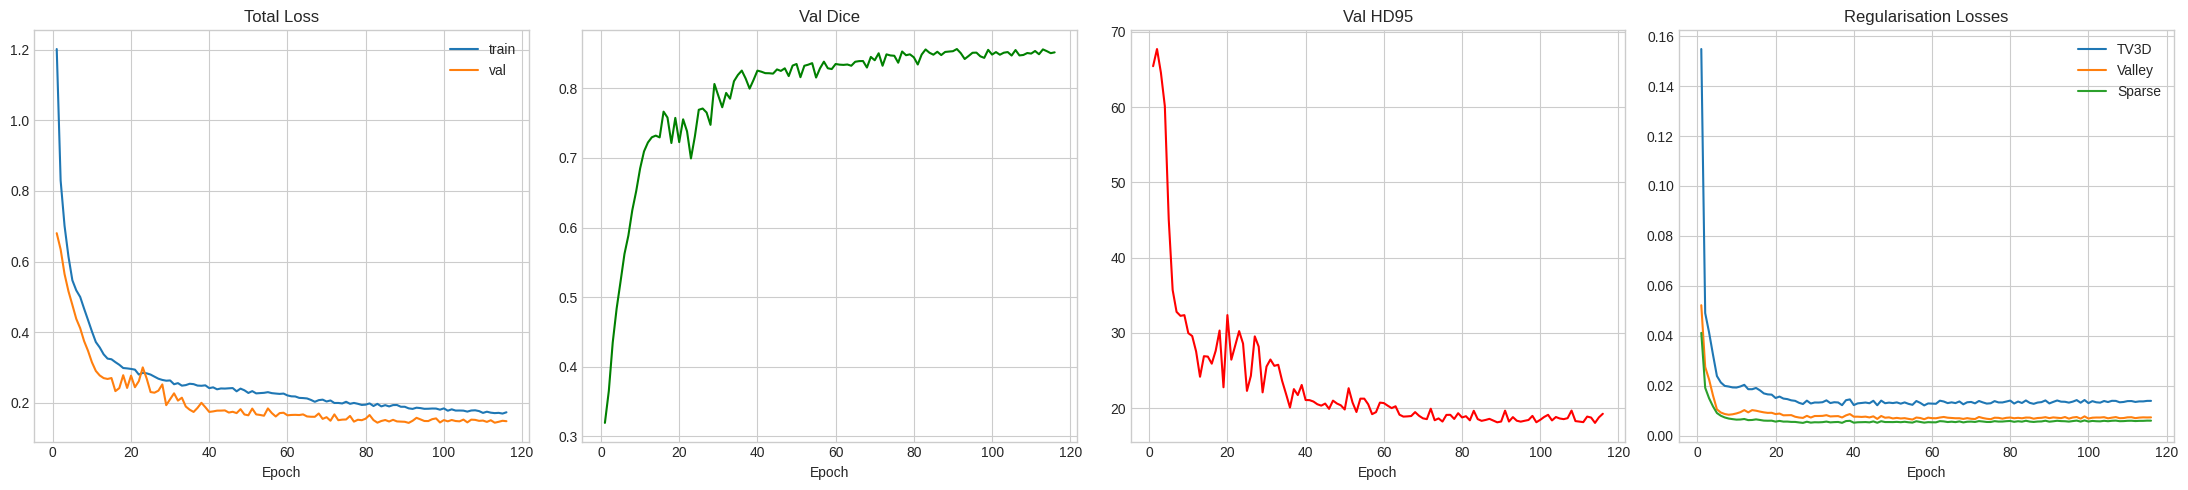

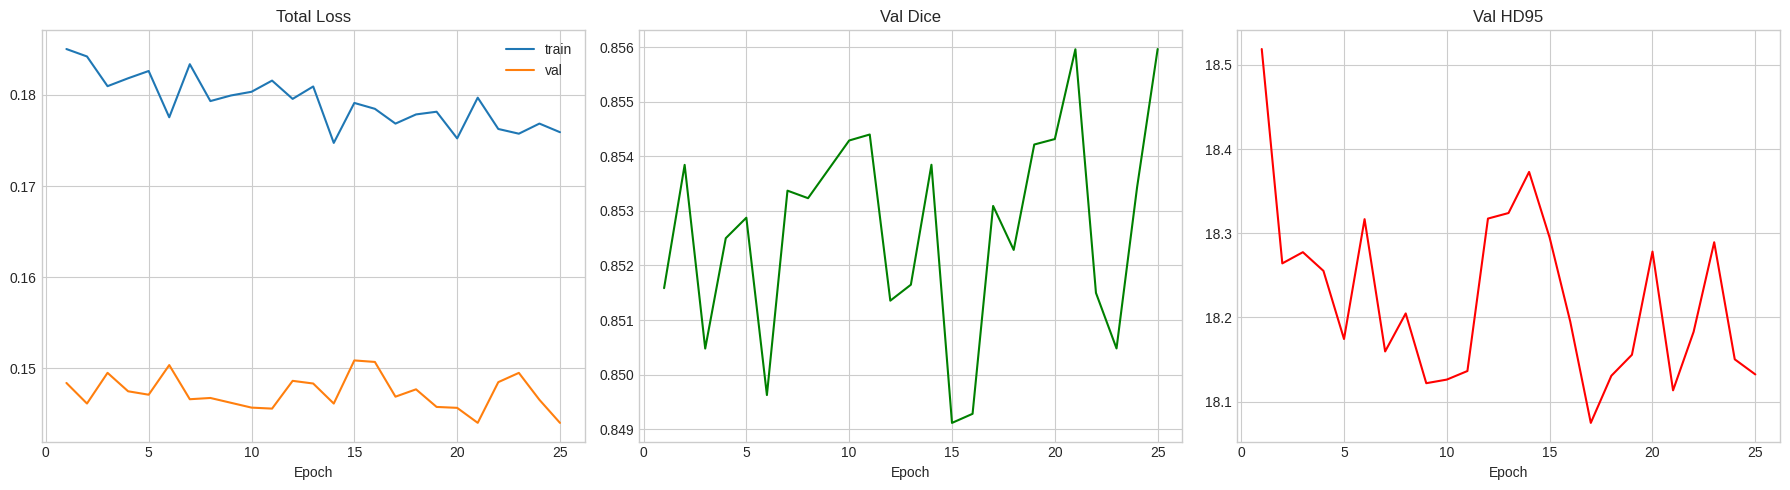

Best Dice: 0.8560


In [45]:
%matplotlib inline
ckpt_path = Path(PATHS['ckpt_dir']) / '3dbreastnet_v35_ft_best.pth'

if ckpt_path.exists():
    ck   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    hist = ck['hist']
    ncols = 4 if 'tv' in hist else 3
    fig, ax = plt.subplots(1, ncols, figsize=(6*ncols, 5))
    ax[0].plot(hist['epoch'], hist['train_loss'], label='train')
    ax[0].plot(hist['epoch'], hist['val_loss'],   label='val')
    ax[0].set_title('Total Loss'); ax[0].legend()
    ax[1].plot(hist['epoch'], hist['val_dice'], color='green')
    ax[1].set_title('Val Dice')
    ax[2].plot(hist['epoch'], hist['val_hd'], color='red')
    ax[2].set_title('Val HD95')
    if ncols == 4:
        ax[3].plot(hist['epoch'], hist['tv'],     label='TV3D')
        ax[3].plot(hist['epoch'], hist['valley'], label='Valley')
        ax[3].plot(hist['epoch'], hist['sparse'], label='Sparse')
        ax[3].set_title('Regularisation'); ax[3].legend()
    for a in ax: a.set_xlabel('Epoch')
    plt.tight_layout(); plt.show()
    print(f"Best Dice: {ck['best_dice']:.4f}")
else:
    print(f'No checkpoint at {ckpt_path} — run training first.')

Running diagnostics on device: cuda

Patients: 137 | B=108 M=29


Loading fine-tuned model checkpoint from: checkpoints_3d_v35/3dbreastnet_v35_ft_best.pth


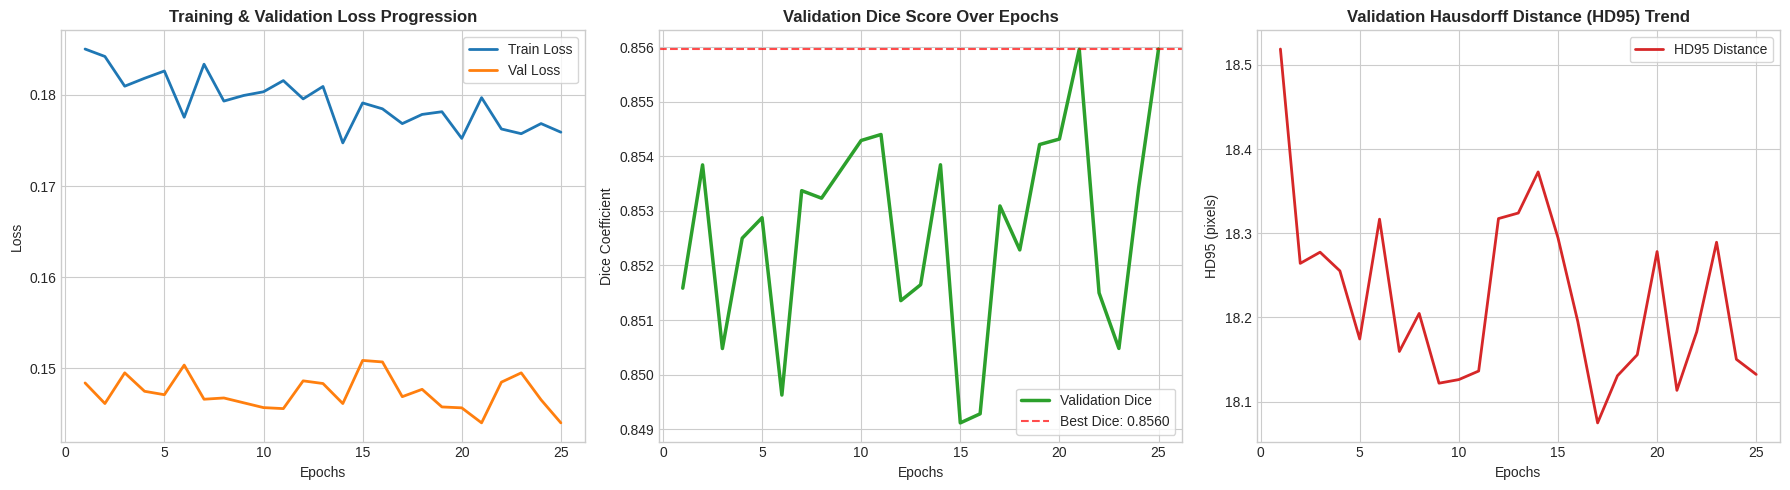

Evaluating Validation Split:   0%|          | 0/31 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════════════════
           DETAILED RECONSTRUCTION METRICS BY ACQUISITION ANGLE
════════════════════════════════════════════════════════════════════════
View Name                      | Mean Dice Score      | Mean HD95 (pixels)  
----------------------------------------------------------------------------
Right Lateral (-90°)           | 0.7642               | 18.62               
Right Oblique (-45°)           | 0.8280               | 18.67               
Frontal (0°)                   | 0.8595               | 11.45               
Left Oblique (45°)             | 0.7951               | 22.02               
Left Lateral (90°)             | 0.7232               | 19.91               
════════════════════════════════════════════════════════════════════════

 Generating side-by-side validation visual audits...


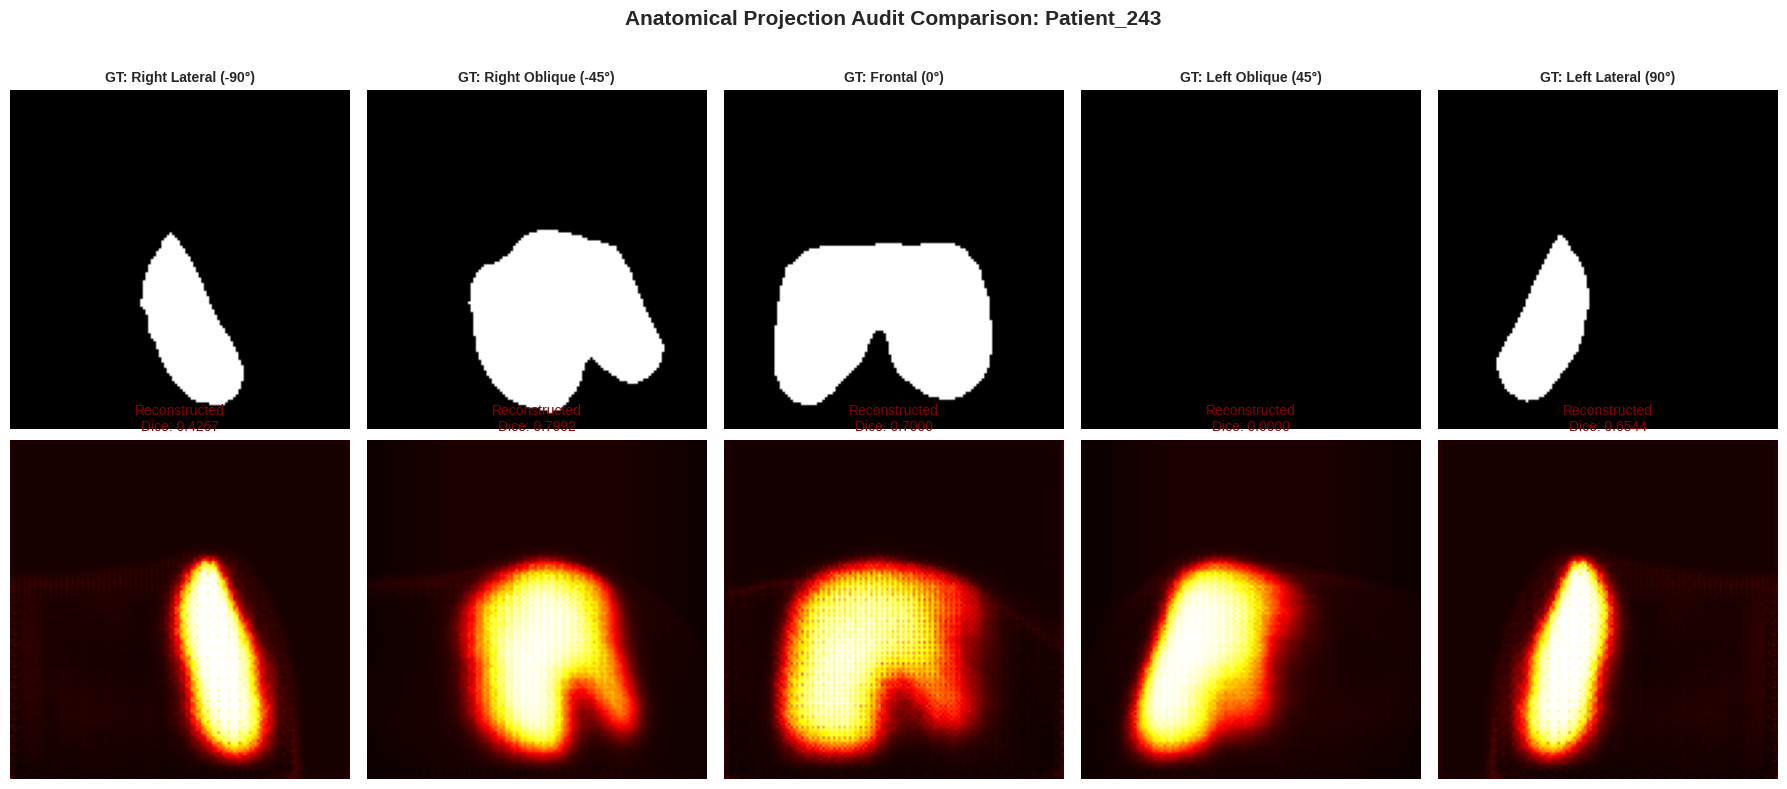

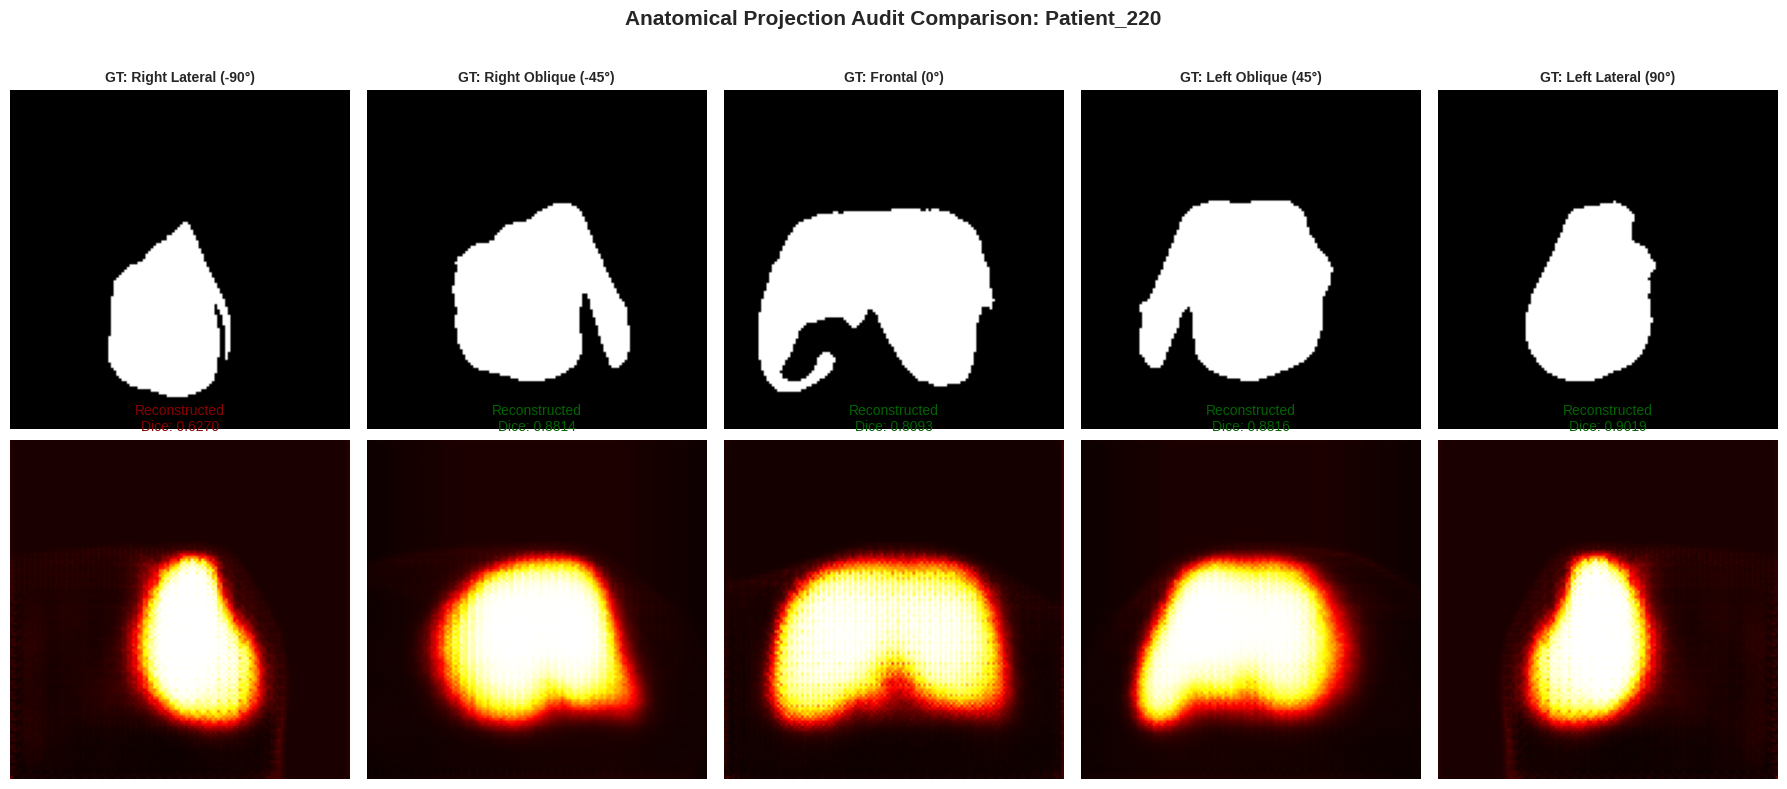

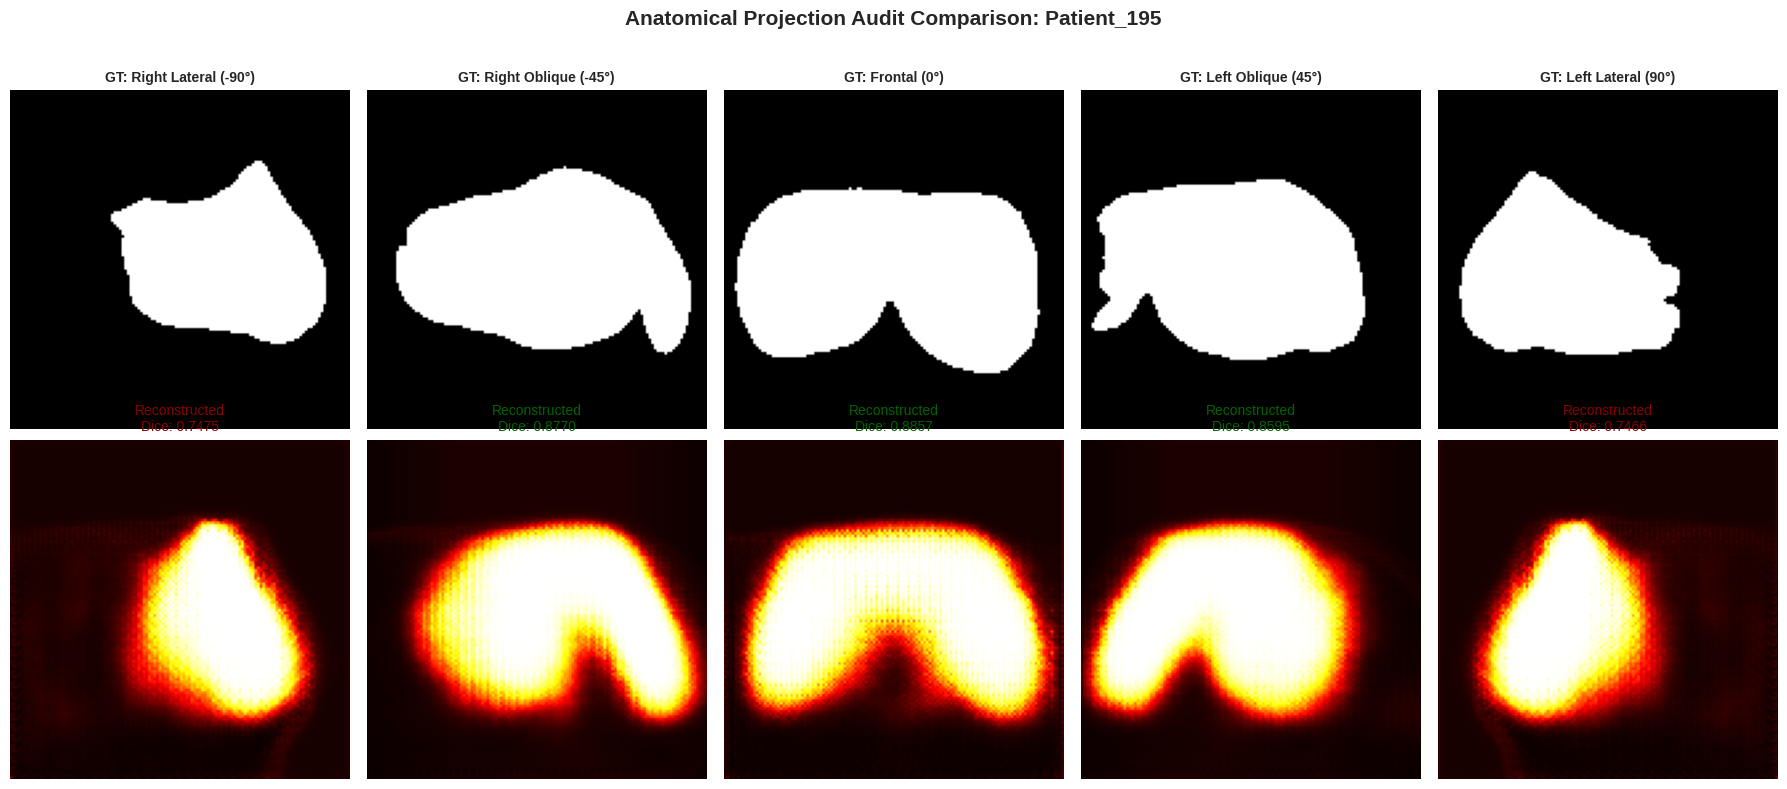

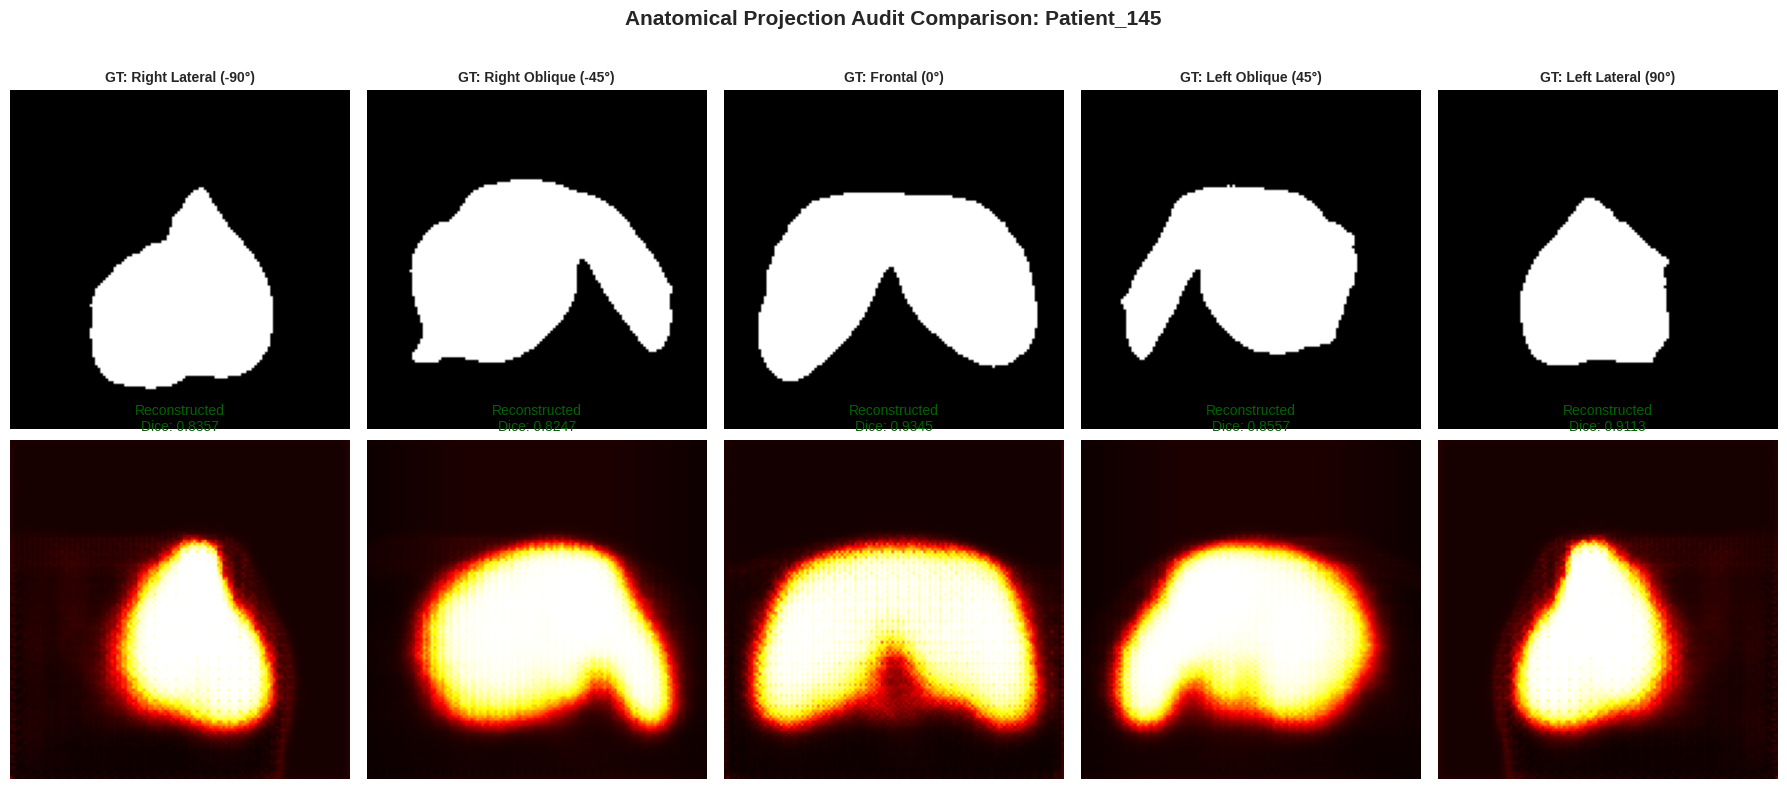

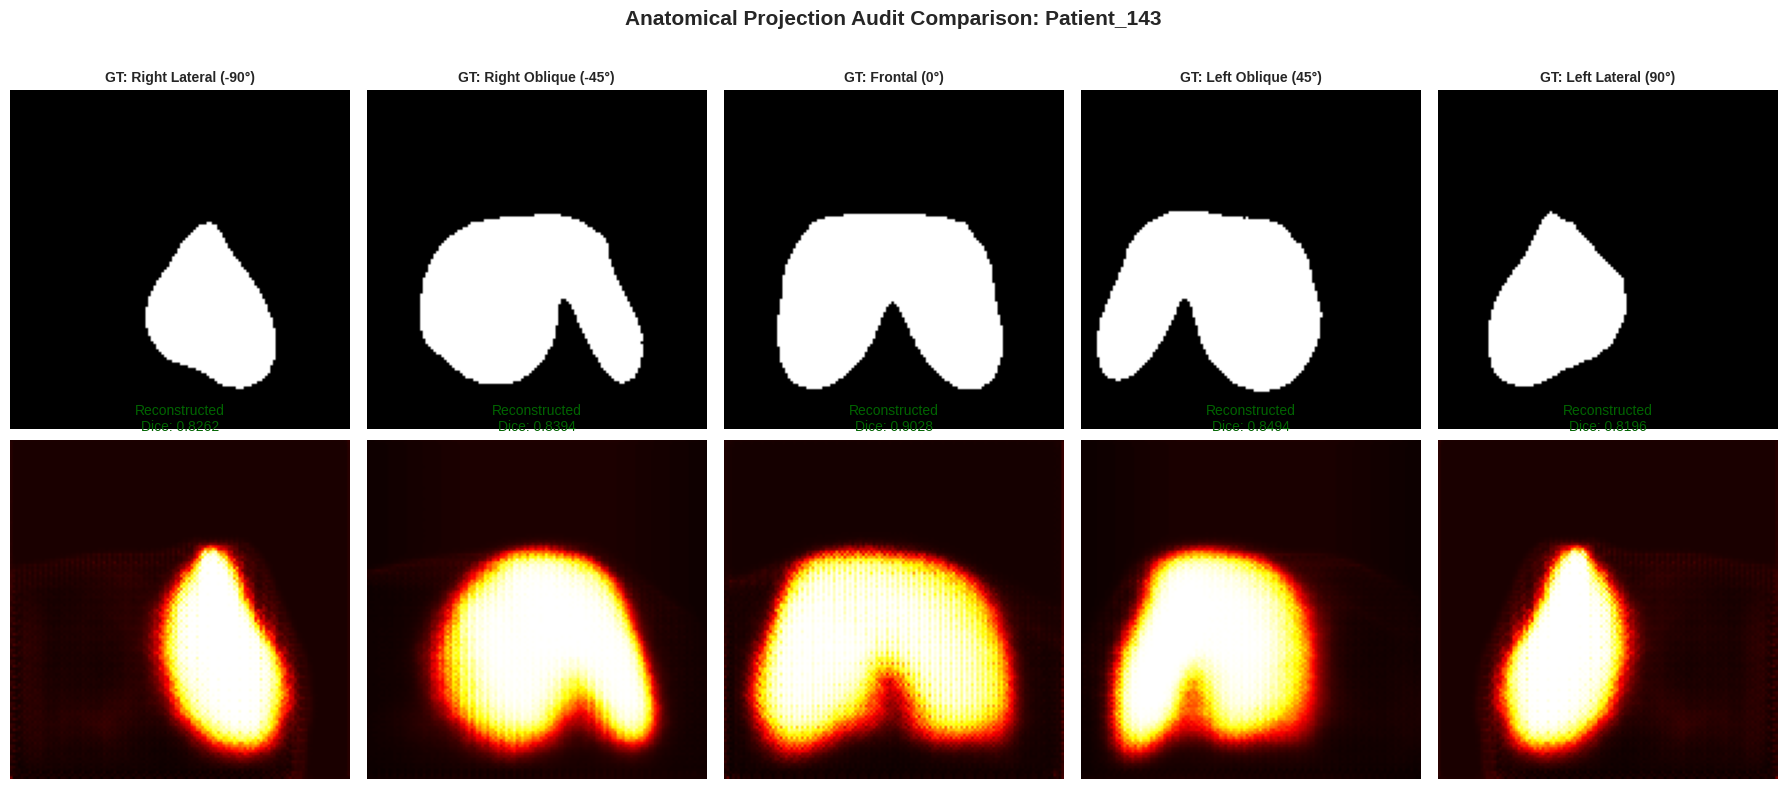

In [46]:
# ════════════════════════════════════════════════════════════════════════════
# 3DBREASTNET v3.5 — POST-FINE-TUNING EVALUATION & VISUAL DASHBOARD
# ════════════════════════════════════════════════════════════════════════════

import os, time, random, math, glob
import numpy as np, cv2, scipy.ndimage
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import torch, torch.nn.functional as F
from torch.utils.data import DataLoader

# 1. Config for Evaluation
EVAL_CFG = {
    "ckpt_dir":     PATHS['ckpt_dir'],
    "best_ckpt":    str(Path(PATHS['ckpt_dir']) / "3dbreastnet_v35_ft_best.pth"),
    "otsu_dir":     PATHS['otsu_dir'],
    "unet_dir":     PATHS['unet_dir'],
    "seed":         SEED,
}

def run_visual_diagnostics(cfg):
    device = DEVICE
    print(f"Running diagnostics on device: {device}\n")

    # ── STRICT VAL SPLIT (Matches Training to prevent Data Leakage) ──
    benign, malignant = build_hybrid_patients(cfg['otsu_dir'], cfg['unet_dir'])
    rng = random.Random(cfg["seed"])
    rng.shuffle(benign); rng.shuffle(malignant)
    s = CFG['train_split']
    val_groups = benign[int(len(benign)*s):] + malignant[int(len(malignant)*s):]
    
    val_dl = DataLoader(HybridPatientDataset(val_groups, cfg["otsu_dir"], cfg["unet_dir"]), 
                        batch_size=1, shuffle=False)

    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    
    ckpt_path = Path(cfg["best_ckpt"])
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Fine-tuned checkpoint not found at {ckpt_path}! (Did FT finish?)")
        
    print(f"Loading fine-tuned model checkpoint from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()

    # PART 1: Plot History
    if "hist" in ckpt:
        hist = ckpt["hist"]
        epochs = hist["epoch"]
        
        plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
        fig, ax = plt.subplots(1, 3, figsize=(18, 5))
        
        ax[0].plot(epochs, hist["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
        ax[0].plot(epochs, hist["val_loss"], label="Val Loss", color="#ff7f0e", linewidth=2)
        ax[0].set_title("Training & Validation Loss Progression", fontsize=12, fontweight='bold')
        ax[0].set_xlabel("Epochs", fontsize=10); ax[0].set_ylabel("Loss", fontsize=10)
        ax[0].legend(frameon=True)
        
        ax[1].plot(epochs, hist["val_dice"], color="#2ca02c", linewidth=2.5, label="Validation Dice")
        ax[1].axhline(y=max(hist["val_dice"]), color="r", linestyle="--", alpha=0.7, label=f"Best Dice: {max(hist['val_dice']):.4f}")
        ax[1].set_title("Validation Dice Score Over Epochs", fontsize=12, fontweight='bold')
        ax[1].set_xlabel("Epochs", fontsize=10); ax[1].set_ylabel("Dice Coefficient", fontsize=10)
        ax[1].legend(frameon=True)
        
        ax[2].plot(epochs, hist["val_hd"], color="#d62728", linewidth=2, label="HD95 Distance")
        ax[2].set_title("Validation Hausdorff Distance (HD95) Trend", fontsize=12, fontweight='bold')
        ax[2].set_xlabel("Epochs", fontsize=10); ax[2].set_ylabel("HD95 (pixels)", fontsize=10)
        ax[2].legend(frameon=True)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Training history not found in checkpoint file.")

    # PART 2: Metrics by Angle
    val_angles = VAL_ANGLES
    view_names = VIEW_NAMES
    
    angle_dices = {ang: [] for ang in val_angles}
    angle_hds = {ang: [] for ang in val_angles}
    
    with torch.no_grad():
        for batch in tqdm(val_dl, desc="Evaluating Validation Split"):
            inp10 = batch["input_10ch"].to(device)
            tgt5 = batch["target_5ch"].to(device)
            B = inp10.size(0)
            
            vol = dec(enc(inp10)).float()
            
            for i, ang in enumerate(val_angles):
                th = torch.full((B,), ang, device=device)
                proj = render_projection(vol, th)
                
                dl = dice_loss(proj, tgt5[:, i:i+1])
                angle_dices[ang].append(1.0 - dl.item())
                
                pb = (proj > 0.5).cpu().numpy()
                mb = (tgt5[:, i:i+1] > 0.5).cpu().numpy()
                for b in range(B):
                    angle_hds[ang].append(hd95(pb[b,0], mb[b,0]))

    print("\n════════════════════════════════════════════════════════════════════════")
    print("           DETAILED RECONSTRUCTION METRICS BY ACQUISITION ANGLE")
    print("════════════════════════════════════════════════════════════════════════")
    print(f"{'View Name':<30} | {'Mean Dice Score':<20} | {'Mean HD95 (pixels)':<20}")
    print("-" * 76)
    for i, ang in enumerate(val_angles):
        print(f"{view_names[i]:<30} | {np.mean(angle_dices[ang]):<20.4f} | {np.mean(angle_hds[ang]):<20.2f}")
    print("════════════════════════════════════════════════════════════════════════\n")

    # PART 3: Visual Audit (Multiple Patients)
    print(" Generating side-by-side validation visual audits...")
    
    # Show the first 5 patients
    num_to_show = 5
    
    for idx, sample_batch in enumerate(val_dl):
        if idx >= num_to_show:
            break
            
        inp10_sample = sample_batch["input_10ch"].to(device)
        tgt5_sample = sample_batch["target_5ch"].to(device)
        pid_sample = sample_batch["patient_id"][0]
        
        with torch.no_grad(): vol_sample = dec(enc(inp10_sample)).float()
            
        fig, axes = plt.subplots(2, 5, figsize=(18, 8))
        fig.suptitle(f"Anatomical Projection Audit Comparison: {pid_sample}", fontsize=15, fontweight='bold', y=0.98)
        
        for i, ang in enumerate(val_angles):
            gt_mask = tgt5_sample[0, i].cpu().numpy()
            axes[0, i].imshow(gt_mask, cmap='gray')
            axes[0, i].set_title(f"GT: {view_names[i]}", fontsize=10, fontweight='bold')
            axes[0, i].axis('off')
            
            th = torch.full((1,), ang, device=device)
            proj_sample = render_projection(vol_sample, th).squeeze().cpu().numpy()
                
            axes[1, i].imshow(proj_sample, cmap='hot')
            
            intersect = np.sum((proj_sample > 0.5) * (gt_mask > 0.5))
            denom = np.sum(proj_sample > 0.5) + np.sum(gt_mask > 0.5)
            ind_dice = (2.0 * intersect + 1e-6) / (denom + 1e-6)
            
            axes[1, i].set_title(f"Reconstructed\nDice: {ind_dice:.4f}", fontsize=10, color='darkgreen' if ind_dice > 0.8 else 'darkred')
            axes[1, i].axis('off')
            
        plt.tight_layout()
        plt.subplots_adjust(top=0.88)
        plt.show()

# Execute the cell
run_visual_diagnostics(EVAL_CFG)

## Cell 15 — STL Mesh Export (FIX 4 + FIX 5)

### FIX 4: Gaussian sigma reduced from 2.0 → 0.8

The original `sigma=2.0` Gaussian blur has a kernel radius of ~6 voxels — completely filling 
the 8-voxel sternal valley that `inter_mammary_valley_loss` worked to carve. 
`sigma=0.8` smooths surface staircasing noise (wavelength ~2 voxels) without destroying 
anatomical features (wavelength 8+ voxels).

### FIX 5: Standardised `marching_cubes` threshold

The original used `level=0.02` in the batch export and `level=0.5` in the test export — 
producing geometrically different meshes from the same volume. Both are now standardised to 
`MC_LEVEL = 0.35`, which corresponds to the same threshold used in `clean_volume_for_export`.

The isosurface $\mathcal{S}$ is defined as:

$$\mathcal{S} = \{(x,y,z) \in \mathbb{R}^3 : V(x,y,z) = 0.35\}$$

Marching Cubes approximates $\mathcal{S}$ by triangulating the boundary between voxels with 
$V > 0.35$ (occupied) and $V \leq 0.35$ (empty).

In [48]:
def save_stl_binary(filename, verts, faces):
    """Write a binary STL without external dependencies."""
    with open(filename, 'wb') as f:
        f.write(b'\0' * 80)
        f.write(struct.pack('<I', len(faces)))
        for face in faces:
            tri = verts[face].astype(np.float32)
            v0, v1, v2 = tri
            n = np.cross(v1 - v0, v2 - v0)
            norm = np.linalg.norm(n)
            n = (n / norm if norm > 0 else np.zeros(3)).astype(np.float32)
            f.write(struct.pack('<3f', *n))
            f.write(struct.pack('<3f', *v0))
            f.write(struct.pack('<3f', *v1))
            f.write(struct.pack('<3f', *v2))
            f.write(struct.pack('<H', 0))


def export_stl_batch(enc, dec, unet, paths=PATHS):
    """
    Batch export all patients to .STL.
    FIX 4: gaussian_filter sigma=0.8 (was 2.0)
    FIX 5: marching_cubes level=MC_LEVEL=0.35 (was 0.02 / 0.5 inconsistently)
    """
    out_dir = Path('exported_stls_v35'); out_dir.mkdir(exist_ok=True)
    groups  = build_patient_groups(paths['tiff_base'])
    dataset = PatientDataset(groups, unet, DEVICE)

    enc.eval(); dec.eval()
    skipped = 0

    for i in tqdm(range(len(dataset)), desc='STL export'):
        item = dataset[i]
        pid  = item['patient_id']

        # FIX 1: use input_10ch
        inp10 = item['input_10ch'].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            vol_np = dec(enc(inp10)).float()[0, 0].cpu().numpy()

        # Pad to force closed mesh at boundaries
        vol_np = np.pad(vol_np, pad_width=1, mode='constant', constant_values=0)

        # FIX 4: sigma=0.8 — smooth staircasing without destroying valley
        vol_np = gaussian_filter(vol_np, sigma=GAUSSIAN_SIGMA)

        try:
            # FIX 5: standardised level=MC_LEVEL=0.35
            verts, faces, _, _ = marching_cubes(vol_np, level=MC_LEVEL)
            verts = verts - 1.0                     # compensate padding
            verts = (verts / 63.5) - 1.0            # normalise to [-1, 1]
            save_stl_binary(out_dir / f'{pid}_v35.stl', verts, faces)
        except Exception as e:
            print(f'Skipping {pid}: {e}'); skipped += 1

    print(f'Export done. {len(dataset)-skipped}/{len(dataset)} meshes saved to {out_dir.absolute()}')


# ── Run (load models first) ──────────────────────────────────────────────────
unet_for_export = UNet().to(DEVICE)
unet_for_export.load_state_dict(torch.load(PATHS['unet_ckpt'], map_location=DEVICE, weights_only=False))
unet_for_export.eval()
ck = torch.load(Path(PATHS['ckpt_dir'])/'3dbreastnet_v35_best.pth', map_location=DEVICE, weights_only=False)
enc_ex = Encoder2D().to(DEVICE); enc_ex.load_state_dict(ck['enc']); enc_ex.eval()
dec_ex = Decoder3D().to(DEVICE); dec_ex.load_state_dict(ck['dec']); dec_ex.eval()
export_stl_batch(enc_ex, dec_ex, unet_for_export)
print('export_stl_batch() defined — uncomment block above to run.')

Complete patients: 122 | B=96 M=26


STL export:   0%|          | 0/122 [00:00<?, ?it/s]

Skipping Patient_144: Surface level must be within volume data range.
Skipping Patient_16: Surface level must be within volume data range.
Skipping Patient_171: Surface level must be within volume data range.
Skipping Patient_182: Surface level must be within volume data range.
Skipping Patient_194: Surface level must be within volume data range.
Skipping Patient_197: Surface level must be within volume data range.
Skipping Patient_220: Surface level must be within volume data range.
Skipping Patient_221: Surface level must be within volume data range.
Skipping Patient_224: Surface level must be within volume data range.
Skipping Patient_226: Surface level must be within volume data range.
Skipping Patient_234: Surface level must be within volume data range.
Skipping Patient_239: Surface level must be within volume data range.
Skipping Patient_256: Surface level must be within volume data range.
Skipping Patient_26: Surface level must be within volume data range.
Skipping Patient_319: 

## Cell 16 — Interactive 3D Thermal Mesh Visualization

After reconstruction, the 2D thermal images are projected onto the 3D mesh surface via 
ray-cast visibility. Only front-facing vertices (positive dot product between surface normal 
and camera direction) receive thermal values:

$$\text{visible}(v) = \begin{cases} 1 & \hat{n}_v \cdot \hat{d}_{cam} > 0 \\ 0 & \text{otherwise} \end{cases}$$

KNN interpolation fills back-projected (occluded) vertices:

$$T(v_{occ}) = \frac{\sum_{k} w_k \cdot T(v_k)}{\sum_k w_k}, \quad w_k = \frac{1}{d(v_{occ}, v_k) + \varepsilon}$$

In [53]:
def compute_thermal_overlay(verts, normals, thermals_5ch, masks_5ch, device=DEVICE):
    """
    Project 5-view thermal images onto 3D mesh vertices.
    Returns per-vertex thermal intensity for Plotly coloring.
    """
    from scipy.spatial import cKDTree

    V = verts.shape[0]
    thermal_acc   = np.zeros(V, dtype=np.float32)
    thermal_count = np.zeros(V, dtype=np.float32)

    angles   = VAL_ANGLES
    t5_np    = thermals_5ch[0].cpu().numpy()  # [5, H, W]
    m5_np    = masks_5ch[0].cpu().numpy()     # [5, H, W]
    H, W     = t5_np.shape[1], t5_np.shape[2]

    # Centre vertices in [-1,1] space for projection
    v_norm = (verts / 63.5) - 1.0

    for i, ang in enumerate(angles):
        rad = np.deg2rad(ang)
        c, s = np.cos(rad), np.sin(rad)
        # Rotate vertices to camera frame
        xr =  c * v_norm[:,0] + s * v_norm[:,2]
        yr =  v_norm[:,1]
        # Rotate normals
        nx_r =  c * normals[:,0] + s * normals[:,2]
        cam_dir = np.array([-np.sin(rad), 0, np.cos(rad)])
        dot = (normals * cam_dir).sum(axis=1)
        visible = dot > 0

        # Map to pixel coords
        px = ((xr + 1) / 2 * (W - 1)).clip(0, W-1).astype(int)
        py = ((yr + 1) / 2 * (H - 1)).clip(0, H-1).astype(int)

        for vi in np.where(visible)[0]:
            if m5_np[i, py[vi], px[vi]] > 0.5:
                thermal_acc[vi]   += t5_np[i, py[vi], px[vi]]
                thermal_count[vi] += 1

    # Fill unsampled vertices with KNN
    sampled_idx   = np.where(thermal_count > 0)[0]
    unsampled_idx = np.where(thermal_count == 0)[0]
    result = np.zeros(V, dtype=np.float32)
    with np.errstate(invalid='ignore'):
        result[sampled_idx] = thermal_acc[sampled_idx] / thermal_count[sampled_idx]

    if len(unsampled_idx) > 0 and len(sampled_idx) > 0:
        tree = cKDTree(verts[sampled_idx])
        _, idx = tree.query(verts[unsampled_idx], k=min(5, len(sampled_idx)))
        result[unsampled_idx] = result[sampled_idx[idx]].mean(axis=1)

    return result


def visualise_patient(enc, dec, unet, patient_idx=0, paths=PATHS):
    """Reconstruct one patient and display interactive 3D thermal mesh."""
    groups  = build_patient_groups(paths['tiff_base'])
    dataset = PatientDataset(groups, unet, DEVICE)
    item    = dataset[patient_idx]
    pid, lbl = item['patient_id'], item['label']

    inp10 = item['input_10ch'].unsqueeze(0).to(DEVICE)
    t5    = item['thermals_5ch'].unsqueeze(0)
    m5    = item['masks_5ch'].unsqueeze(0).to(DEVICE)

    enc.eval(); dec.eval()
    with torch.no_grad():
        vol_np = dec(enc(inp10)).float()[0, 0].cpu().numpy()

    vol_np = np.pad(vol_np, 1, mode='constant', constant_values=0)
    vol_np = gaussian_filter(vol_np, sigma=GAUSSIAN_SIGMA)  # FIX 4

    try:
        verts, faces, normals, _ = marching_cubes(vol_np, level=MC_LEVEL)  # FIX 5
        verts_disp = verts - 1.0
        thermal    = compute_thermal_overlay(verts_disp, normals, t5, m5.cpu())

        fig = go.Figure(data=[go.Mesh3d(
            x=verts_disp[:,2], y=verts_disp[:,0], z=-verts_disp[:,1],
            i=faces[:,0], j=faces[:,1], k=faces[:,2],
            colorscale='Jet', intensity=thermal,
            showscale=True, colorbar_title='Thermal<br>Intensity'
        )])
        fig.update_layout(
            title=f'Patient: {pid} | {lbl} (v3.5 Reconstruction)',
            scene=dict(
                xaxis_title='Width (X)', yaxis_title='Depth (Y)', zaxis_title='Height (Z)',
                aspectmode='data',
                camera=dict(up=dict(x=0,y=0,z=1), eye=dict(x=0,y=1.5,z=0.2))
            ),
            margin=dict(l=0,r=0,b=0,t=40)
        )
        fig.show()
    except ValueError as e:
        print(f'Mesh generation failed for {pid}: {e}')


visualise_patient(enc_ex, dec_ex, unet_for_export, patient_idx=0)
print('visualise_patient() defined — load models from Cell 15 and uncomment.')

Complete patients: 122 | B=96 M=26


IndexError: index 138 is out of bounds for axis 2 with size 128

## Cell 17 — Per-Patient Projection Validation Grid

For each patient, generates a 2×5 grid comparing ground-truth U-Net masks (top row) 
against the binarised 3D→2D projections (bottom row) at the five canonical angles. 
Per-view Dice scores are printed in the subplot titles.

In [55]:
def evaluate_all_patients(enc, dec, unet, paths=PATHS, out_dir='projection_plots_v35'):
    Path(out_dir).mkdir(exist_ok=True)
    groups  = build_patient_groups(paths['tiff_base'])
    dataset = PatientDataset(groups, unet, DEVICE)
    enc.eval(); dec.eval()
    all_dices = []

    for item in tqdm(dataset, desc='Evaluating'):
        pid = item['patient_id']
        inp10 = item['input_10ch'].unsqueeze(0).to(DEVICE)
        m5    = item['masks_5ch'].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            vol = dec(enc(inp10)).float()  # PURE FP32 — no autocast
            patient_dices, projections = [], []
            for i, ang in enumerate(VAL_ANGLES):
                th   = torch.tensor([ang], device=DEVICE)
                proj = render_projection(vol, th)
                d    = 1.0 - dice_loss(proj, m5[:, i:i+1]).item()
                patient_dices.append(d)
                projections.append((proj[0,0] > 0.5).cpu().numpy().astype(np.float32))

        all_dices.append(np.mean(patient_dices))

        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        fig.suptitle(f'{pid} | Mean Dice: {np.mean(patient_dices):.4f}', fontsize=15)
        for i in range(5):
            axes[0,i].imshow(m5[0,i].cpu().numpy(), cmap='gray')
            axes[0,i].set_title(f'GT: {VIEW_NAMES[i]}'); axes[0,i].axis('off')
            axes[1,i].imshow(projections[i], cmap='gray')
            axes[1,i].set_title(f'Pred (Dice={patient_dices[i]:.3f})')
            axes[1,i].axis('off')
        plt.tight_layout()
        plt.savefig(Path(out_dir) / f'{pid}_v35_grid.png', dpi=130)
        plt.close(fig)

    print(f'\nAll patients evaluated.')
    print(f'Overall Mean Dice : {np.mean(all_dices):.4f}')
    print(f'Std               : {np.std(all_dices):.4f}')
    print(f'Plots saved to    : {Path(out_dir).absolute()}')


evaluate_all_patients(enc_ex, dec_ex, unet_for_export)
print('evaluate_all_patients() defined — load models and uncomment.')

Complete patients: 122 | B=96 M=26


Evaluating:   0%|          | 0/122 [00:00<?, ?it/s]


All patients evaluated.
Overall Mean Dice : 0.8428
Std               : 0.0698
Plots saved to    : /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/HybridPlan/projection_plots_v35
evaluate_all_patients() defined — load models and uncomment.
